In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import json
from pathlib import Path

# path1 = "/users/avazhentsev/agents_with_uncertainty_research/experiments/orchestration_hypothesis_testing/data/final_confidence_bayes_quality_logprobs_allcrit_c1/mbpp/deepseek_v4_pro/final_logprob_bayes_quality.csv"
# path2 = "/users/avazhentsev/agents_with_uncertainty_research/experiments/orchestration_hypothesis_testing/data/final_confidence_bayes_quality_logprobs_5/mbpp/deepseek_v4_pro/final_logprob_bayes_quality.csv"
base_path1 = "/capstor/store/cscs/swissai/a0142/agents_uq/final_confidence_lcb_medium_gpt_oss_120b_slurm_2354303/lcb_medium/gpt_oss_120b_local/"
base_path2 = "/capstor/store/cscs/swissai/a0142/agents_uq/final_confidence_lcb_hard_gpt_oss_120b_slurm_2355104/lcb_hard/gpt_oss_120b_local/"
base_path3 = "/capstor/store/cscs/swissai/a0142/agents_uq/final_confidence_lcb_hard_gpt_oss_120b_slurm_2355996/lcb_hard/gpt_oss_120b_local/"
base_path4 = "/users/avazhentsev/agents_with_uncertainty_research/experiments/orchestration_hypothesis_testing/sim_results/lcb_llm_tool_agent_gpt_oss_120b_finalverify/"
base_path5 = "/users/avazhentsev/agents_with_uncertainty_research/experiments/orchestration_hypothesis_testing/sim_results/lcb_llm_tool_agent_gpt_oss_120b_autogen/readable_sage_latest/"
base_path6 = "/capstor/store/cscs/swissai/a0142/agents_uq/lcb_llm_tool_agent_gpt_oss_120b/2367717_20260524_135543/"
base_path6 = "/capstor/store/cscs/swissai/a0142/agents_uq/lcb_llm_tool_agent_gpt_oss_120b/2367716_20260524_135530/"
base_path6 = "/capstor/store/cscs/swissai/a0142/agents_uq/lcb_llm_tool_agent_gpt_oss_120b/2367715_20260524_135527/"
base_path6 = "/capstor/store/cscs/swissai/a0142/agents_uq/lcb_llm_tool_agent_gpt_oss_20b/2368761_20260524_153248/" #lcb-hard
base_path6 = "/capstor/store/cscs/swissai/a0142/agents_uq/lcb_llm_tool_agent_gpt_oss_20b/2368762_20260524_153248/" #lcb-medium

# base_path6 = "/capstor/store/cscs/swissai/a0142/agents_uq/lcb_llm_tool_agent_qwen25_32b/2372042_20260524_191604/" #lcb-medium
# base_path6 = "/capstor/store/cscs/swissai/a0142/agents_uq/lcb_llm_tool_agent_qwen25_32b/2372041_20260524_190958/" #lcb-hard

results = pd.read_csv(base_path6 + "readable/final_logprob_bayes_quality.csv")
results_traj = pd.read_csv(base_path6 + "readable/generation_trajectory_scores.csv")
tool_success = pd.read_csv(base_path6 + "tool_success_by_instance.csv")   

summary_path = Path(base_path6) / "readable" / "analysis_summary.json"
prior = json.loads(summary_path.read_text())["prior"]["prior_Y1"]

# base_path5 = "/users/avazhentsev/agents_with_uncertainty_research/experiments/orchestration_hypothesis_testing/sim_results/lcb_llm_tool_agent_gpt_oss_120b_autogen/readable_sage_latest/"

# results = pd.read_csv(base_path5 + "final_logprob_bayes_quality.csv")
# results_traj = pd.read_csv(base_path5 + "generation_trajectory_scores.csv")
# tool_success = pd.read_csv(base_path5 + "tool_success_by_instance.csv")   

In [2]:
results_traj.sort_values(["instance_id", "patch_idx"]).groupby("instance_id").last().bayes_state_after_generation.values

array([0.90427578, 0.735125  , 0.8853125 , 0.90427578, 0.85625   ,
       0.5225    , 0.5225    , 0.87386281, 0.89839062, 0.88971334,
       0.8853125 , 0.8853125 , 0.85625   , 0.85625   , 0.89839062,
       0.8853125 , 0.79166667, 0.89839062, 0.85625   , 0.50109383,
       0.89839062, 0.89839062, 0.89839062, 0.90427578, 0.8853125 ,
       0.8853125 , 0.8853125 , 0.89839062, 0.8853125 , 0.90427578,
       0.85625   , 0.8853125 , 0.89839062, 0.85625   , 0.8853125 ,
       0.87386281, 0.90427578, 0.83080625, 0.8853125 , 0.8853125 ,
       0.90427578, 0.5225    , 0.79166667, 0.89839062, 0.72549222,
       0.5225    , 0.735125  , 0.87386281, 0.8853125 , 0.79166667,
       0.85625   , 0.89839062, 0.50109383, 0.94999153, 0.735125  ,
       0.79166667, 0.85625   , 0.79166667, 0.90427578, 0.79166667,
       0.85625   , 0.5225    , 0.85625   , 0.8853125 , 0.8853125 ,
       0.89839062, 0.94670863, 0.50567268, 0.90427578, 0.735125  ,
       0.5225    , 0.5       , 0.79166667, 0.89839062, 0.79166

In [3]:
results_traj.columns

Index(['benchmark', 'split', 'generator', 'model_id', 'policy', 'instance_id',
       'patch_idx', 'action_step', 'bayes_state_at_generation',
       'bayes_state_after_generation', 'llm_perplexity', 'perplexity',
       'llm_log_seq_prob', 'n_logprob_tokens', 'logprobs_supported',
       'prompt_tokens', 'completion_tokens', 'api_cost_usd', 'candidate_chars',
       'raw_response_chars', 'is_final_candidate', 'final_quality',
       'final_bayes_state', 'final_action'],
      dtype='str')

In [4]:
results = results[results["split"] == "test"].copy()
results_traj = results_traj[results_traj["split"] == "test"].copy()

last_gen = (
    results_traj
    .sort_values(["instance_id", "patch_idx"])
    .groupby("instance_id", as_index=False)
    .last()[["instance_id", "bayes_state_after_generation"]]
)

results = (
    results
    .drop(columns=["bayes_state_after_generation"], errors="ignore")
    .merge(last_gen, on="instance_id", how="left")
)

results["tool_success"] = (
    tool_success["tool_no_final_before_verify_pass_success_rate"]
    .fillna(prior)
)

# results["tool_success"] = tool_success.tool_no_final_before_verify_pass_success_rate.fillna(0.5)
# (tool_success.critic_success_per_all.fillna(1) + tool_success.verifier_success_per_all.fillna(1))

# results = results.dropna(subset=["llm_perplexity"])
# results = results.fillna(1)

In [5]:
tool_success.columns

Index(['instance_id', 'quality', 'final_action', 'n_steps', 'critic_n',
       'critic_ok', 'critic_success_rate', 'verifier_n', 'verifier_ok',
       'verifier_success_rate', 'verifier_no_final_n', 'verifier_no_final_ok',
       'verifier_no_final_success_rate', 'tool_n', 'tool_ok',
       'tool_success_rate', 'tool_no_final_n', 'tool_no_final_ok',
       'tool_no_final_success_rate', 'tool_no_final_before_verify_pass_n',
       'tool_no_final_before_verify_pass_ok',
       'tool_no_final_before_verify_pass_success_rate',
       'verifier_no_final_before_verify_pass_n',
       'verifier_no_final_before_verify_pass_ok', 'critic_success_per_all',
       'verifier_success_per_all', 'verifier_no_final_success_per_all',
       'critic_skipped', 'verifier_skipped', 'verifier_no_final_skipped',
       'tool_no_final_before_verify_pass_skipped', 'critic_L0_n',
       'critic_L0_ok', 'critic_L1_n', 'critic_L1_ok', 'critic_L2_n',
       'critic_L2_ok', 'critic_L3_n', 'critic_L3_ok', 'verify_n',

In [6]:
tool_success

,instance_id,quality,final_action,n_steps,critic_n,critic_ok,critic_success_rate,verifier_n,verifier_ok,verifier_success_rate,...,critic_L1_n,critic_L1_ok,critic_L2_n,critic_L2_ok,critic_L3_n,critic_L3_ok,verify_n,verify_ok,final_verify_n,final_verify_ok
0,3150,0,final_verify_fail,7,0,0,NaN,2,0,0.0,...,0,0,0,0,0,0,1,0,1,0
1,3279,1,verify_pass,11,8,7,0.875000,1,1,1.0,...,1,0,0,0,0,0,1,1,0,0
2,2916,1,verify_pass,4,0,0,NaN,1,1,1.0,...,0,0,0,0,0,0,1,1,0,0
3,2882,1,verify_pass,7,0,0,NaN,1,1,1.0,...,0,0,0,0,0,0,1,1,0,0
4,3195,1,verify_pass,4,0,0,NaN,1,1,1.0,...,0,0,0,0,0,0,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
150,3541,1,verify_pass,6,0,0,NaN,1,1,1.0,...,0,0,0,0,0,0,1,1,0,0
151,2802,1,verify_pass,3,0,0,NaN,1,1,1.0,...,0,0,0,0,0,0,1,1,0,0
152,3213,0,final_verify_fail,19,10,1,0.100000,4,0,0.0,...,1,0,0,0,0,0,3,0,1,0
153,3517,1,verify_pass,14,9,0,0.000000,2,1,0.5,...,4,0,1,0,0,0,2,1,0,0


In [7]:
results.isna().sum()

benchmark                       0
split                           0
generator                       0
model_id                        0
policy                          0
instance_id                     0
llm_perplexity                  0
llm_log_seq_prob                0
bayes_state                     0
quality                         0
perplexity                      0
final_action                    0
bayes_state_after_generation    0
tool_success                    0
dtype: int64

In [8]:
# results["bayes_state_at_generation"] = results_traj.sort_values(["instance_id", "patch_idx"]).groupby("instance_id").last().bayes_state_at_generation.values
# results["bayes_state_after_generation"] = results_traj.sort_values(["instance_id", "patch_idx"]).groupby("instance_id").last().bayes_state_after_generation.values
results

,benchmark,split,generator,model_id,policy,instance_id,llm_perplexity,llm_log_seq_prob,bayes_state,quality,perplexity,final_action,bayes_state_after_generation,tool_success
0,lcb_medium,test,gpt_oss_20b_local,openai/gpt-oss-20b,llm_tool_agent,3150,-0.684055,-2736.221608,0.050000,0,1.981899,final_verify_fail,0.898391,0.000000
1,lcb_medium,test,gpt_oss_20b_local,openai/gpt-oss-20b,llm_tool_agent,3279,-0.513670,-438.160679,0.996095,1,1.671414,verify_pass,0.946709,0.875000
2,lcb_medium,test,gpt_oss_20b_local,openai/gpt-oss-20b,llm_tool_agent,2916,-0.720734,-1744.175837,0.885312,1,2.055941,verify_pass,0.885312,0.648148
3,lcb_medium,test,gpt_oss_20b_local,openai/gpt-oss-20b,llm_tool_agent,2882,-0.680024,-741.225625,0.904276,1,1.973924,verify_pass,0.904276,0.648148
4,lcb_medium,test,gpt_oss_20b_local,openai/gpt-oss-20b,llm_tool_agent,3195,-0.620745,-950.980651,0.885312,1,1.860313,verify_pass,0.885312,0.648148
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
150,lcb_medium,test,gpt_oss_20b_local,openai/gpt-oss-20b,llm_tool_agent,3541,-0.796227,-627.426960,0.904276,1,2.217160,verify_pass,0.904276,0.648148
151,lcb_medium,test,gpt_oss_20b_local,openai/gpt-oss-20b,llm_tool_agent,2802,-0.581296,-637.681318,0.856250,1,1.788354,verify_pass,0.856250,0.648148
152,lcb_medium,test,gpt_oss_20b_local,openai/gpt-oss-20b,llm_tool_agent,3213,-0.310139,-548.015418,0.709405,0,1.363614,final_verify_fail,0.501094,0.076923
153,lcb_medium,test,gpt_oss_20b_local,openai/gpt-oss-20b,llm_tool_agent,3517,-0.320417,-194.813463,0.501094,1,1.377702,verify_pass,0.501094,0.000000


In [9]:
results['quality'].mean()

np.float64(0.7806451612903226)

In [10]:
results.bayes_state.nunique(), results.bayes_state.value_counts()

(55,
 bayes_state
 8.562500e-01    21
 8.853125e-01    20
 8.983906e-01    18
 9.042758e-01    13
 5.000000e-02    12
 7.916667e-01    12
 5.225000e-01     4
 7.351250e-01     3
 5.222553e-06     2
 9.999031e-01     2
 9.353907e-01     2
 2.417861e-07     2
 9.996023e-01     2
 9.960950e-01     1
 5.000000e-01     1
 9.499999e-01     1
 9.907329e-01     1
 3.477425e-07     1
 9.912613e-01     1
 9.977747e-01     1
 9.925160e-01     1
 9.953215e-01     1
 8.308062e-01     1
 2.631709e-11     1
 2.339850e-03     1
 9.990340e-01     1
 9.969777e-01     1
 9.993468e-01     1
 9.551465e-01     1
 9.981409e-01     1
 9.926816e-01     1
 2.037253e-01     1
 9.591799e-01     1
 5.000000e-01     1
 9.963860e-01     1
 9.818110e-08     1
 9.786877e-01     1
 9.997889e-01     1
 9.999723e-01     1
 8.738628e-01     1
 9.863058e-01     1
 9.963018e-01     1
 9.992979e-01     1
 9.991864e-01     1
 9.799513e-01     1
 1.077433e-08     1
 9.514751e-01     1
 9.385855e-01     1
 5.857202e-11     1
 9

In [11]:
from lm_polygraph.ue_metrics import PredictionRejectionArea
from lm_polygraph.ue_metrics.ue_metric import (
    get_random_scores,
    normalize_metric,
)
from sklearn.metrics import roc_auc_score

prrs = {"PRR": PredictionRejectionArea(), 
        "PRR_05": PredictionRejectionArea(max_rejection=0.5), 
        "Spearmanr": stats.spearmanr,
        "AUROC": lambda y_true, y_score: roc_auc_score(y_true, y_score),}

/users/avazhentsev/miniconda3/envs/thinkbooster/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [12]:
results["llm_perplexity"].values

array([-0.6840554 , -0.5136702 , -0.72073382, -0.68002351, -0.62074455,
       -0.64829681, -0.4290679 , -0.60840726, -0.38367726, -0.56422278,
       -0.41791024, -0.47224971, -0.68664949, -0.53680096, -0.5840701 ,
       -0.46893466, -0.61419869, -0.32283155, -0.54510798, -0.67048273,
       -0.56808696, -0.38206124, -0.28850723, -0.5646581 , -0.65464461,
       -0.30145639, -0.51553667, -0.41260072, -0.50905329, -0.33114681,
       -0.61583107, -0.38970296, -0.62034138, -0.77674195, -0.3734226 ,
       -0.57421832, -0.45329939, -0.42205658, -0.73171986, -0.51445532,
       -0.50452681, -0.43158021, -0.68914228, -0.49415469, -0.6941227 ,
       -0.41829491, -0.49695604, -0.57827275, -0.44277217, -0.46350819,
       -0.6956616 , -0.55999489, -0.66738371, -0.4952293 , -0.6791494 ,
       -0.57226845, -0.53198193, -0.28360687, -0.64643756, -0.41678869,
       -0.48820671, -0.4738722 , -0.55660984, -0.46708051, -0.41952867,
       -0.49868373, -0.61108389, -0.56432811, -0.64613492, -0.64

In [13]:
df = {}
for prr in prrs:
    df[prr] = {}
    for col in ["llm_perplexity", "llm_log_seq_prob", "bayes_state", "bayes_state_after_generation", "tool_success"]:
        if col == "quality":
            continue
        if prr == "Spearmanr":
            normalized_score = prrs[prr](results[col], results["quality"]).statistic
        elif prr == "AUROC":
            normalized_score = prrs[prr](results["quality"].values, results[col].values)
        else:
            ue_metric = prrs[prr](-results[col].values, results["quality"].values)
            oracle_score = prrs[prr](-results["quality"].values, results["quality"].values)
            random_score = get_random_scores(prrs[prr], results["quality"])
            normalized_score = normalize_metric(ue_metric, oracle_score, random_score)
        df[prr][col] = normalized_score
        print("End-to-end {} for {}: {}".format(prr, col, normalized_score))
df = pd.DataFrame(df)
df.style.background_gradient()

End-to-end PRR for llm_perplexity: 0.2521591323211114
End-to-end PRR for llm_log_seq_prob: 0.8437372472010464
End-to-end PRR for bayes_state: 0.7714460190949959
End-to-end PRR for bayes_state_after_generation: 0.032367313933154354
End-to-end PRR for tool_success: 0.828086102022666
End-to-end PRR_05 for llm_perplexity: 0.15560443444225802
End-to-end PRR_05 for llm_log_seq_prob: 0.7888746576833316
End-to-end PRR_05 for bayes_state: 0.8201517828496456
End-to-end PRR_05 for bayes_state_after_generation: 0.37448729239033085
End-to-end PRR_05 for tool_success: 0.8423511580519639
End-to-end Spearmanr for llm_perplexity: 0.1404238467596892
End-to-end Spearmanr for llm_log_seq_prob: 0.5742394527542625
End-to-end Spearmanr for bayes_state: 0.5775196506950129
End-to-end Spearmanr for bayes_state_after_generation: 0.21501829378488937
End-to-end Spearmanr for tool_success: 0.6373370103802773
End-to-end AUROC for llm_perplexity: 0.5979581915410793
End-to-end AUROC for llm_log_seq_prob: 0.90058337384

,PRR,PRR_05,Spearmanr,AUROC
llm_perplexity,0.252159,0.155604,0.140424,0.597958
llm_log_seq_prob,0.843737,0.788875,0.574239,0.900583
bayes_state,0.771446,0.820152,0.577520,0.901313
bayes_state_after_generation,0.032367,0.374487,0.215018,0.648639
tool_success,0.828086,0.842351,0.637337,0.906417


In [271]:
df = {}
for prr in prrs:
    df[prr] = {}
    for col in ["llm_perplexity", "llm_log_seq_prob", "bayes_state", "bayes_state_after_generation"]:#, "tool_success"]:
        if col == "quality":
            continue
        if prr == "Spearmanr":
            normalized_score = prrs[prr](results[col], results["quality"]).statistic
        elif prr == "AUROC":
            normalized_score = prrs[prr](results["quality"].values, results[col].values)
        else:
            ue_metric = prrs[prr](-results[col].values, results["quality"].values)
            oracle_score = prrs[prr](-results["quality"].values, results["quality"].values)
            random_score = get_random_scores(prrs[prr], results["quality"])
            normalized_score = normalize_metric(ue_metric, oracle_score, random_score)
        df[prr][col] = normalized_score
        print("End-to-end {} for {}: {}".format(prr, col, normalized_score))
df = pd.DataFrame(df)
df.style.background_gradient()

End-to-end PRR for llm_perplexity: 0.5798875753229269


End-to-end PRR for llm_log_seq_prob: 0.6820189936227697
End-to-end PRR for bayes_state: 0.7600733737235108
End-to-end PRR for bayes_state_after_generation: 0.2394083948661828
End-to-end PRR_05 for llm_perplexity: 0.5568071785647176
End-to-end PRR_05 for llm_log_seq_prob: 0.6694877466700473
End-to-end PRR_05 for bayes_state: 0.6445597473241867
End-to-end PRR_05 for bayes_state_after_generation: 0.3464679325549274
End-to-end Spearmanr for llm_perplexity: 0.4343020034193732
End-to-end Spearmanr for llm_log_seq_prob: 0.5185969070366355
End-to-end Spearmanr for bayes_state: 0.5564706958072388
End-to-end Spearmanr for bayes_state_after_generation: 0.3862934730730718
End-to-end AUROC for llm_perplexity: 0.7801418439716312
End-to-end AUROC for llm_log_seq_prob: 0.83451536643026
End-to-end AUROC for bayes_state: 0.8516548463356973
End-to-end AUROC for bayes_state_after_generation: 0.6625295508274232


,PRR,PRR_05,Spearmanr,AUROC
llm_perplexity,0.579888,0.556807,0.434302,0.780142
llm_log_seq_prob,0.682019,0.669488,0.518597,0.834515
bayes_state,0.760073,0.644560,0.556471,0.851655
bayes_state_after_generation,0.239408,0.346468,0.386293,0.662530


### Bayes state -> action paths

Map `results.bayes_state.value_counts()` back to concrete controller action paths, then plot the counts by path.


results: /capstor/store/cscs/swissai/a0142/agents_uq/final_confidence_lcb_hard_gpt_oss_120b_slurm_2355996/lcb_hard/gpt_oss_120b_local/final_logprob_bayes_quality.csv
actions: /capstor/store/cscs/swissai/a0142/agents_uq/final_confidence_lcb_hard_gpt_oss_120b_slurm_2355996/lcb_hard/gpt_oss_120b_local/controller_actions.jsonl


,path_id,action_path,n,quality_mean,final_actions,bayes_states,bayes_states_after_generation,examples
0,P01,generate -> L1_lint+ -> L0_syntax+ -> verify+,49,1.0,verify_pass:49,0.826934,0.476692,"2784, 2808, 2827, 2879, 2921, 3017, 3025, 3032, 3153, 3184"
1,P02,generate -> L1_lint- -> generate -> generate -> L0_syntax- -> generate -> generate -> L0_syntax- -> generate -> generate -> L0_syntax- -> generate -> generate -> L0_syntax- -> generate -> generate -> L0_syntax- -> generate -> generate -> L0_syntax- -> generate -> generate -> L0_syntax- -> generate -> generate -> L0_syntax- -> generate -> L0_syntax- -> generate -> L0_syntax- -> generate -> L0_syntax- -> bail_out -> label_verifier-,7,0.0,bail:7,0.008813,0.215220,"2952, 3203, 3298, 3327, 3701, 3733, 3789"
2,P03,generate -> L1_lint+ -> L0_syntax+ -> verify- -> generate -> generate -> L0_syntax+ -> L1_lint+ -> L2_public_tests+ -> verify+,3,1.0,verify_pass:3,0.932898,0.336765,"2849, 3364, 3571"
3,P04,generate -> L1_lint- -> generate -> generate -> L0_syntax+ -> L1_lint+ -> L2_public_tests+ -> verify+,2,1.0,verify_pass:2,0.932074,0.333847,"3532, 3765"
4,P05,generate -> L1_lint+ -> L0_syntax+ -> verify- -> generate -> generate -> L0_syntax+ -> L1_lint+ -> L2_public_tests+ -> verify- -> generate -> generate -> L0_syntax+ -> L1_lint+ -> L2_public_tests+ -> verify- -> generate -> generate -> L0_syntax+ -> L1_lint+ -> L2_public_tests+ -> verify- -> generate -> generate -> L0_syntax+ -> L1_lint+ -> L2_public_tests+ -> verify- -> generate -> generate -> L0_syntax+ -> L1_lint+ -> L2_public_tests+ -> verify- -> generate -> generate -> L0_syntax+ -> L1_lint+ -> L2_public_tests+ -> verify- -> generate -> generate -> L0_syntax+ -> L1_lint+ -> L2_public_tests+ -> verify- -> generate -> generate -> L0_syntax+ -> L1_lint+ -> L2_public_tests+ -> verify- -> generate -> L1_lint+ -> L0_syntax+ -> L2_public_tests+ -> verify- -> bail_out,2,0.0,bail:2,0.894864,0.237143,"2839, 3575"
5,P06,generate -> L1_lint+ -> L0_syntax+ -> verify- -> generate -> generate -> L0_syntax- -> generate -> generate -> L0_syntax+ -> L1_lint+ -> L2_public_tests+ -> verify+,1,1.0,verify_pass:1,0.930142,0.327185,2919
6,P07,generate -> L1_lint+ -> L0_syntax+ -> verify- -> generate -> generate -> L0_syntax- -> generate -> generate -> L0_syntax+ -> L1_lint+ -> L2_public_tests+ -> verify- -> generate -> generate -> L0_syntax+ -> L1_lint+ -> L2_public_tests+ -> verify+,1,1.0,verify_pass:1,0.932898,0.336765,3770
7,P08,generate -> L1_lint+ -> L0_syntax- -> generate -> generate -> L0_syntax- -> generate -> generate -> L0_syntax- -> generate -> generate -> L0_syntax+ -> L1_lint+ -> L2_public_tests+ -> verify- -> generate -> generate -> L0_syntax+ -> L1_lint+ -> L2_public_tests+ -> verify+,1,1.0,verify_pass:1,0.932898,0.336765,3551
8,P09,generate -> L1_lint+ -> L0_syntax- -> generate -> generate -> L0_syntax- -> generate -> generate -> L0_syntax- -> generate -> generate -> L0_syntax- -> generate -> generate -> L0_syntax- -> generate -> generate -> L0_syntax- -> generate -> generate -> L0_syntax- -> generate -> generate -> L0_syntax- -> generate -> generate -> L0_syntax+ -> L1_lint+ -> L2_public_tests+ -> verify+,1,1.0,verify_pass:1,0.930085,0.326991,3316
9,P10,generate -> L1_lint+ -> L0_syntax+ -> verify- -> generate -> generate -> L0_syntax+ -> L1_lint+ -> L2_public_tests+ -> verify- -> generate -> generate -> L0_syntax+ -> L1_lint+ -> L2_public_tests+ -> verify- -> generate -> generate -> L0_syntax+ -> L1_lint+ -> L2_public_tests+ -> verify- -> generate -> generate -> L0_syntax+ -> L1_lint+ -> L2_public_tests+ -> verify- -> generate -> generate -> L0_syntax+ -> L1_lint+ -> L2_public_tests+ -> verify- -> generate -> generate -> L0_syntax+ -> L1_lint+ -> L2_public_tests+ -> verify- -> generate -> generate -> L0_syntax- -> generate -> generate -> L0_syntax- -> generate -> L0_syntax+ -> L1_lint+ -> L2_public_tests+ -> verify- -> generate -> L1_lint+ -> L0_syntax+ -> L2_public_tests+ -> verify- -> generate -> L1_lint+ -> L2_public_tests+

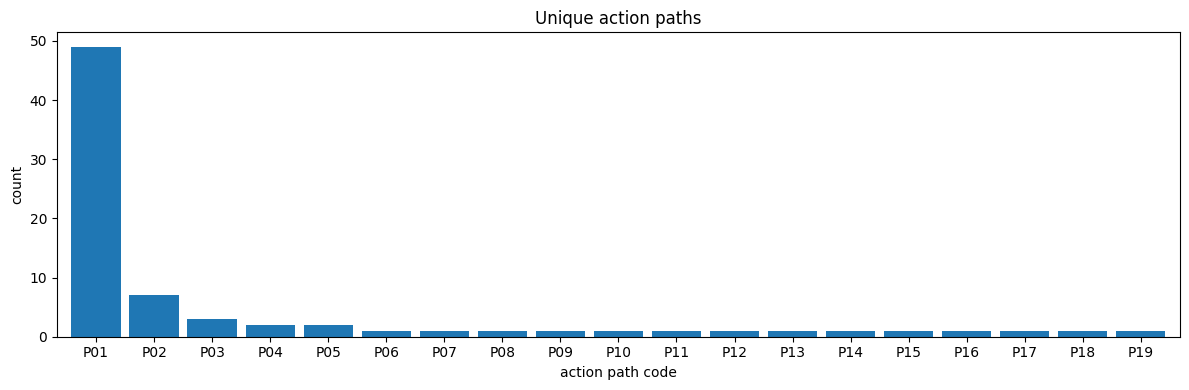

In [102]:
from pathlib import Path
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option('display.max_colwidth', None)
results_path = Path(base_path3) / "final_logprob_bayes_quality.csv"
meta_path = results_path.with_suffix(".jsonl")
actions_path = results_path.parent / "controller_actions.jsonl"
results_traj = pd.read_csv(base_path3 + "generation_trajectory_scores.csv")

final = pd.read_json(meta_path, lines=True)
actions = pd.read_json(actions_path, lines=True)
final["bayes_state_after_generation"] = results_traj.sort_values(["instance_id", "patch_idx"]).groupby("instance_id").last().bayes_state_after_generation.values


def action_token(row):
    action = str(row["action"])
    if action == "generate" or action.startswith("generate"):
        return "generate"
    if action.startswith("critic:"):
        name = action.split(":", 1)[1]
        return f"{name}{'+' if bool(row.get('passed')) else '-'}"
    if action == "verify":
        return f"verify{'+' if bool(row.get('ok')) else '-'}"
    if action == "label_verifier":
        return f"label_verifier{'+' if bool(row.get('ok')) else '-'}"
    return action


actions = actions.sort_values(["instance_id", "policy", "step", "ts"])
actions["action_token"] = actions.apply(action_token, axis=1)

paths = (
    actions.groupby(["instance_id", "policy"], as_index=False)
    .agg(action_path=("action_token", " -> ".join))
)

analysis = final[["instance_id", "policy", "bayes_state", "bayes_state_after_generation", "quality", "final_action"]].merge(
    paths, on=["instance_id", "policy"], how="left"
)
analysis["action_path"] = analysis["action_path"].fillna("(no controller_actions rows)")

path_table = (
    analysis.groupby("action_path", dropna=False)
    .agg(
        n=("instance_id", "size"),
        quality_mean=("quality", "mean"),
        final_actions=("final_action", lambda s: ", ".join(f"{k}:{v}" for k, v in s.value_counts().items())),
        bayes_states=("bayes_state", lambda s: ", ".join(f"{x:.6f}" for x in sorted(s.dropna().unique(), reverse=True))),
        bayes_states_after_generation=("bayes_state_after_generation", lambda s: ", ".join(f"{x:.6f}" for x in sorted(s.dropna().unique(), reverse=True))),
        examples=("instance_id", lambda s: ", ".join(map(str, s.head(10)))),
    )
    .reset_index()
    .sort_values(["n", "quality_mean"], ascending=[False, False])
    .reset_index(drop=True)
)
path_table.insert(0, "path_id", [f"P{i:02d}" for i in range(1, len(path_table) + 1)])

print(f"results: {results_path}")
print(f"actions: {actions_path}")
display(path_table)

ax = path_table.plot.bar(x="path_id", y="n", figsize=(12, 4), legend=False, width=0.85)
ax.set_title("Unique action paths")
ax.set_xlabel("action path code")
ax.set_ylabel("count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

results: /capstor/store/cscs/swissai/a0142/agents_uq/lcb_llm_tool_agent_gpt_oss_120b/2367715_20260524_135527/readable/final_logprob_bayes_quality.csv
actions: /capstor/store/cscs/swissai/a0142/agents_uq/lcb_llm_tool_agent_gpt_oss_120b/2367715_20260524_135527/controller_actions.jsonl


,path_id,action_path,n,quality_mean,final_actions,bayes_states,bayes_states_after_generation,examples
0,P01,generate -> verify+,42,1.0,verify_pass:42,0.773214,0.773214,"3680, 3658, 3725, 3571, 2879, 3560, 2849, 3032, 3631, 3439"
1,P02,generate -> think -> verify+,2,1.0,verify_pass:2,0.773214,0.773214,"3223, 3466"
2,P03,generate -> verify- -> L0_syntax- -> L1_lint- -> L2_public_tests- -> L3_llm_review- -> think -> generate -> verify+,2,1.0,verify_pass:2,0.500134,0.500134,"3777, 3783"
3,P04,generate -> L0_syntax+ -> L1_lint- -> L0_syntax+ -> L0_syntax+ -> L0_syntax+ -> L0_syntax+ -> verify+,1,1.0,verify_pass:1,0.999630,0.773214,2921
4,P05,generate -> L0_syntax+ -> L1_lint- -> L1_lint- -> L2_public_tests+ -> L3_llm_review+ -> verify+,1,1.0,verify_pass:1,0.981007,0.773214,3362
5,P06,generate -> L0_syntax+ -> L1_lint- -> L2_public_tests+ -> L3_llm_review+ -> verify- -> think -> generate -> L0_syntax+ -> L1_lint- -> L2_public_tests+ -> L3_llm_review+ -> verify+,1,1.0,verify_pass:1,0.941486,0.522500,2919
6,P07,generate -> L0_syntax- -> L1_lint- -> L2_public_tests- -> L3_llm_review- -> L0_syntax- -> think -> generate -> L0_syntax+ -> L1_lint- -> L1_lint- -> L2_public_tests+ -> L3_llm_review- -> verify+,1,1.0,verify_pass:1,0.938228,0.500642,3687
7,P08,generate -> L0_syntax- -> L1_lint- -> L2_public_tests- -> L3_llm_review- -> generate -> verify- -> verify- -> generate -> verify:skipped -> generate -> generate -> generate -> L0_syntax+ -> L1_lint- -> L2_public_tests- -> L2_public_tests- -> L3_llm_review- -> L3_llm_review- -> generate -> L3_llm_review+ -> L3_llm_review+ -> finish -> final_verify+,1,1.0,final_verify_pass:1,0.557999,0.557999,3688
8,P09,generate -> L0_syntax- -> L1_lint- -> L2_public_tests- -> L3_llm_review- -> think -> generate -> L0_syntax+ -> L1_lint- -> L2_public_tests+ -> L3_llm_review+ -> verify+,1,1.0,verify_pass:1,0.938322,0.508509,3025
9,P10,generate -> L2_public_tests+ -> verify+,1,1.0,verify_pass:1,0.927955,0.773214,3364


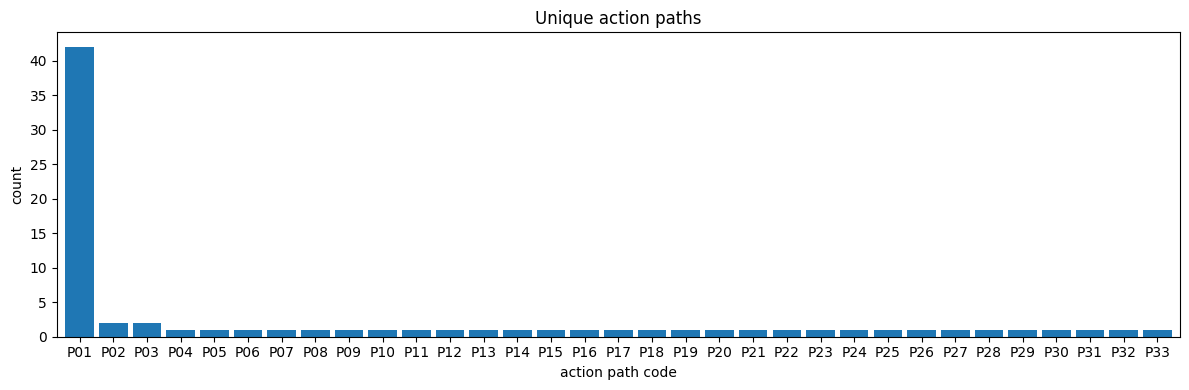

In [295]:
from pathlib import Path
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_colwidth", None)

results_path = Path(base_path6) / "readable/final_logprob_bayes_quality.csv"
meta_path = results_path.with_suffix(".jsonl")
actions_path = results_path.parent.parent / "controller_actions.jsonl"
traj_path = Path(base_path6) / "readable/generation_trajectory_scores.csv"

results_traj = pd.read_csv(traj_path)
final = pd.read_json(meta_path, lines=True)
actions = pd.read_json(actions_path, lines=True)

final = final[final["split"].fillna("test").eq("test")].copy()
actions = actions[actions["split"].fillna("test").eq("test")].copy()
results_traj = results_traj[results_traj["split"].fillna("test").eq("test")].copy()

last_gen = (
    results_traj
    .sort_values(["instance_id", "patch_idx"])
    .groupby("instance_id", as_index=False)
    .last()[["instance_id", "bayes_state_after_generation"]]
)

final = (
    final
    .drop(columns=["bayes_state_after_generation"], errors="ignore")
    .merge(last_gen, on="instance_id", how="left")
)

def action_token(row):
    action = str(row["action"])

    if action == "generate":
        return "generate"

    if action in {"critic_L0", "critic_L1", "critic_L2", "critic_L3"}:
        name = {
            "critic_L0": "L0_syntax",
            "critic_L1": "L1_lint",
            "critic_L2": "L2_public_tests",
            "critic_L3": "L3_llm_review",
        }[action]
        passed = row.get("passed")
        if pd.isna(passed):
            return f"{name}:skipped"
        return f"{name}{'+' if bool(passed) else '-'}"

    if action in {"verify", "final_verify"}:
        passed = row.get("passed")
        if pd.isna(passed):
            return f"{action}:skipped"
        return f"{action}{'+' if bool(passed) else '-'}"

    if action == "think" and row.get("reasoning") == "decision parse failed":
        return "think_parse_failed"

    return action

sort_cols = [c for c in ["instance_id", "policy", "step"] if c in actions.columns]
actions = actions.sort_values(sort_cols)
actions["policy"] = actions.get("policy", "llm_tool_agent")
final["policy"] = final.get("policy", "llm_tool_agent")
actions["action_token"] = actions.apply(action_token, axis=1)

paths = (
    actions.groupby(["instance_id", "policy"], as_index=False)
    .agg(action_path=("action_token", " -> ".join))
)

analysis = final[[
    "instance_id",
    "policy",
    "bayes_state",
    "bayes_state_after_generation",
    "quality",
    "final_action",
]].merge(paths, on=["instance_id", "policy"], how="left")

analysis["action_path"] = analysis["action_path"].fillna("(no controller_actions rows)")

path_table = (
    analysis.groupby("action_path", dropna=False)
    .agg(
        n=("instance_id", "size"),
        quality_mean=("quality", "mean"),
        final_actions=("final_action", lambda s: ", ".join(f"{k}:{v}" for k, v in s.value_counts().items())),
        bayes_states=("bayes_state", lambda s: ", ".join(f"{x:.6f}" for x in sorted(s.dropna().unique(), reverse=True))),
        bayes_states_after_generation=("bayes_state_after_generation", lambda s: ", ".join(f"{x:.6f}" for x in sorted(s.dropna().unique(), reverse=True))),
        examples=("instance_id", lambda s: ", ".join(map(str, s.head(10)))),
    )
    .reset_index()
    .sort_values(["n", "quality_mean"], ascending=[False, False])
    .reset_index(drop=True)
)

path_table.insert(0, "path_id", [f"P{i:02d}" for i in range(1, len(path_table) + 1)])

print(f"results: {results_path}")
print(f"actions: {actions_path}")
display(path_table)

ax = path_table.plot.bar(x="path_id", y="n", figsize=(12, 4), legend=False, width=0.85)
ax.set_title("Unique action paths")
ax.set_xlabel("action path code")
ax.set_ylabel("count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()